# tap.harmony~ — the harmonizer, measured

The multi-voice harmonizer behind `tap.harmony~` (`taptools/harmonizer.h`): up to four
formant-preserving phase-vocoder voices at fractional-semitone intervals, summed with a dry
path the kernel delays into alignment. Every measurement below drives the **shipping C++**
through `tools/capi` via ctypes — the same code the Max external compiles — and uses the
shared DspTap YIN detector as the pitch oracle, the house pattern.

Sections: **1** every interval lands · **2** the dry path is sample-aligned ·
**3** formants stay home · **4** a chord, and the glide.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import taptools_py as tap

plt.rcParams.update({
    "figure.dpi": 96, "figure.figsize": (9, 3.2),
    "axes.grid": True, "grid.alpha": 0.3,
})
C = tap.PALETTE

sr = 48000.0
HOP = 256

def saw(freq_or_track, seconds=None, harmonics=12):
    """Band-limited saw; freq may be a scalar or a per-sample frequency track."""
    if np.isscalar(freq_or_track):
        f = np.full(int(seconds * sr), float(freq_or_track))
    else:
        f = np.asarray(freq_or_track)
    phase = np.cumsum(f) / sr
    x = sum(np.sin(2 * np.pi * h * phase) / h for h in range(1, harmonics + 1))
    return x / np.abs(x).max()

def track_hz(x):
    """Pitch track (Hz, NaN where unvoiced) via the shared DspTap detector."""
    periods = tap.Yin().track(x, hop=HOP)
    hz = np.where(periods > 0, sr / np.maximum(periods, 1e-9), np.nan)
    t = (np.arange(len(hz)) * HOP + tap.Yin().frame_size) / sr
    return t, hz

def cents(f, ref):
    return 1200 * np.log2(f / ref)

def spectrum_db(x, tail=1 << 15):
    """Hann-windowed magnitude spectrum of the signal's tail, in dB re max."""
    seg = x[-tail:] * np.hanning(tail)
    mag = np.abs(np.fft.rfft(seg))
    f = np.fft.rfftfreq(tail, 1 / sr)
    db = 20 * np.log10(np.maximum(mag, 1e-12))
    return f, db - db.max()

## 1 · Every interval lands

One voice solo (`dry 0`), a 220 Hz sawtooth in, the commanded interval swept across two
octaves of useful voicings. The YIN oracle measures the output; the bars are the error in
cents against the exact equal-tempered target. The kernel's Catch battery pins ±10 cents;
the measured errors sit far inside it.

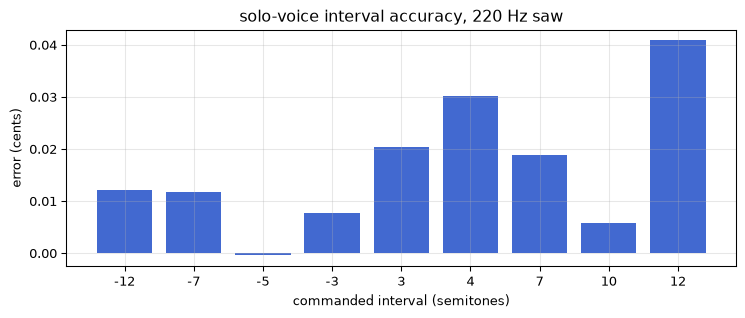

max |error| = 0.04 cents


In [2]:
intervals = [-12, -7, -5, -3, 3, 4, 7, 10, 12]
errors = []
for st in intervals:
    hz = tap.Harmonizer(sr, dry=0.0).chord([st])
    y = hz.process(saw(220.0, seconds=1.5))
    _, track = track_hz(y[int(0.5 * sr):])
    measured = np.nanmedian(track)
    errors.append(cents(measured, 220.0 * 2 ** (st / 12)))

fig, ax = plt.subplots()
ax.bar([str(s) for s in intervals], errors, color=C[0])
ax.set_xlabel("commanded interval (semitones)")
ax.set_ylabel("error (cents)")
ax.set_title("solo-voice interval accuracy, 220 Hz saw")
plt.show()
print(f"max |error| = {np.max(np.abs(errors)):.2f} cents")

## 2 · The dry path is sample-aligned

At interval 0 the phase vocoder reconstructs its input delayed by exactly one FFT frame
(pinned in DspTap). The kernel delays the dry path by the same amount, so `dry 1` plus a
unity voice at interval 0 must equal exactly **2 × the delayed input**. The residual is
numerical noise — this is why chords land as chords instead of flams.

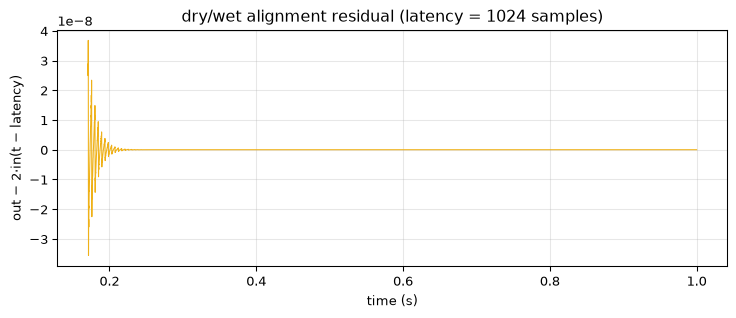

max |residual| after settle = 3.68e-08


In [3]:
hz = tap.Harmonizer(sr, dry=1.0).chord([0.0])
x = saw(220.0, seconds=1.0)
y = hz.process(x)
lat = hz.latency
err = y[8192:] - 2.0 * x[8192 - lat:-lat]

fig, ax = plt.subplots()
t = (np.arange(len(err)) + 8192) / sr
ax.plot(t, err, color=C[1], lw=0.8)
ax.set_xlabel("time (s)")
ax.set_ylabel("out − 2·in(t − latency)")
ax.set_title(f"dry/wet alignment residual (latency = {lat} samples)")
plt.show()
print(f"max |residual| after settle = {np.max(np.abs(err)):.2e}")

## 3 · Formants stay home

The point of the object. A synthetic "voice": 240 Hz source whose harmonics are shaped by
a fixed resonance at 960 Hz — the envelope is the identity, the harmonics are the pitch.
Shift a fifth up (+7) with `formant` on and off. Off, the whole spectrum — bump included —
rides up the full ratio to ~1440 Hz: the chipmunk. On, the harmonics move while the LPC
correction holds the envelope most of the way home (the band centroid below quantifies
exactly how far): the same person, higher.

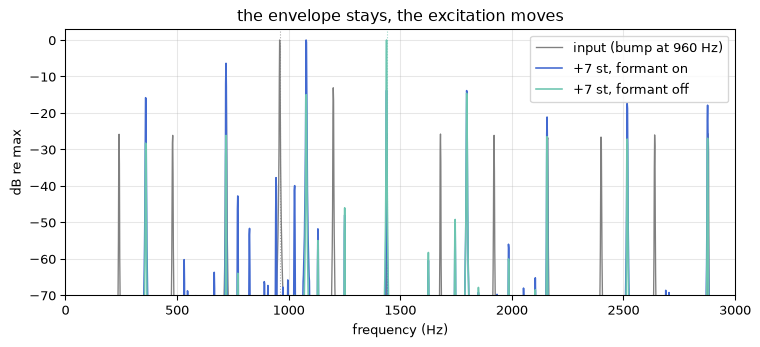

spectral centroid of the 0.6-2.2 kHz band: input 1058 Hz, formant on 1154 Hz, off 1439 Hz


In [4]:
def formant_voice(f0=240.0, center=960.0, seconds=1.5):
    t = np.arange(int(seconds * sr))
    x = sum((np.exp(-(((f0 * h) - center) / 180.0) ** 2) + 0.05)
            * np.sin(2 * np.pi * f0 * h * t / sr) for h in range(1, 26))
    return x / np.abs(x).max()

x = formant_voice()
runs = {}
for on in (True, False):
    hz = tap.Harmonizer(sr, dry=0.0, formant=on).chord([7.0])
    runs[on] = hz.process(x)

fig, ax = plt.subplots(figsize=(9, 3.6))
f, db = spectrum_db(x)
ax.plot(f, db, color="gray", lw=1.0, label="input (bump at 960 Hz)")
f, db = spectrum_db(runs[True])
ax.plot(f, db, color=C[0], lw=1.2, label="+7 st, formant on")
f, db = spectrum_db(runs[False])
ax.plot(f, db, color=C[3], lw=1.2, label="+7 st, formant off")
for fc, c in [(960.0, "gray"), (960.0 * 2 ** (7 / 12), C[3])]:
    ax.axvline(fc, color=c, lw=0.8, ls=":", alpha=0.7)
ax.set_xlim(0, 3000)
ax.set_ylim(-70, 3)
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel("dB re max")
ax.set_title("the envelope stays, the excitation moves")
ax.legend(loc="upper right")
plt.show()

def bump_centroid(y):
    f, db = spectrum_db(y)
    band = (f > 600) & (f < 2200)
    w = 10 ** (db[band] / 20)
    return float(np.sum(f[band] * w) / np.sum(w))

print(f"spectral centroid of the 0.6-2.2 kHz band: input {bump_centroid(x):.0f} Hz, "
      f"formant on {bump_centroid(runs[True]):.0f} Hz, off {bump_centroid(runs[False]):.0f} Hz")

## 4 · A chord, and the glide

Left: the "715 - CRΞΞKS"-school stack from the book's recipe — `chord -12 3 7` with the
dry voice inside it — as a spectrum: four fundamentals from one input. Right: the `glide`
control walking one voice from unison to the octave through a 300 ms one-pole — the pitch
travels, it doesn't jump (and no group of human singers can do this).

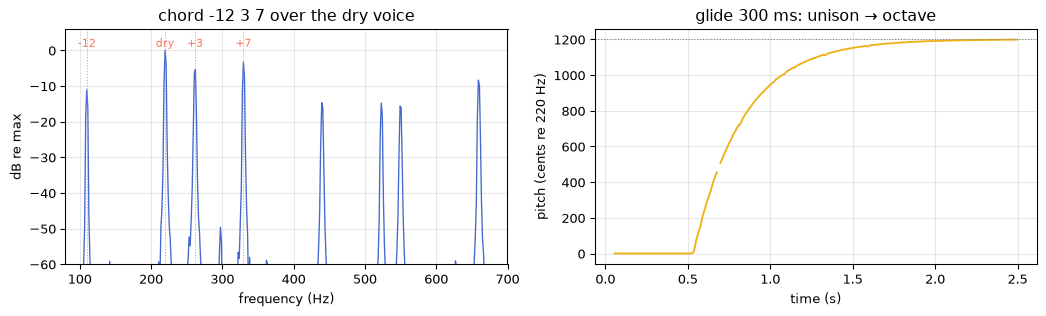

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.4))

hz = tap.Harmonizer(sr, dry=1.0).chord([-12, 3, 7])
y = hz.process(saw(220.0, seconds=1.5))
f, db = spectrum_db(y)
ax1.plot(f, db, color=C[0], lw=1.0)
for st in (-12, 0, 3, 7):
    fc = 220.0 * 2 ** (st / 12)
    ax1.axvline(fc, color=C[2], lw=0.8, ls=":", alpha=0.8)
    ax1.text(fc, 1, f"{st:+d}" if st else "dry", ha="center", fontsize=8, color=C[2])
ax1.set_xlim(80, 700)
ax1.set_ylim(-60, 6)
ax1.set_xlabel("frequency (Hz)")
ax1.set_ylabel("dB re max")
ax1.set_title("chord -12 3 7 over the dry voice")

hz = tap.Harmonizer(sr, dry=0.0, glide=300.0).chord([0.0])
a = hz.process(saw(220.0, seconds=0.5))
hz.set(intervals=[12.0])
b = hz.process(saw(220.0, seconds=2.0))
t, trk = track_hz(np.concatenate([a, b]))
ax2.plot(t, cents(trk, 220.0), color=C[1], lw=1.4)
ax2.axhline(1200, color="gray", lw=0.8, ls=":")
ax2.set_xlabel("time (s)")
ax2.set_ylabel("pitch (cents re 220 Hz)")
ax2.set_title("glide 300 ms: unison → octave")
plt.tight_layout()
plt.show()

---

Every number above is the shipping kernel measured through its C ABI; the same contract
points are pinned CI-side in `tests/harmonizer_test.cpp` (intervals under the YIN oracle,
dry alignment to 1e-6, the formant bump staying home, the glide walking through the
middle). The book's recipe — *A choir of one* — cites this notebook and those tests.